In [938]:
from pathlib import Path

import cv2
import numpy as np

from draftslice.core.io import load_image

files = sorted(Path("../data/images").glob("*.jpg"))

In [939]:
from draftslice.core.ocr.engine import OCREngine, PaddleOCRParameters
from draftslice.core.ocr.pipeline import run as run_ocr

# Тяжёлые модели грузим один раз, не на каждое изображение.
ocr_engine = OCREngine(PaddleOCRParameters(text_rec_score_thresh=0.5))

Creating model: ('PP-OCRv6_medium_det', '../models/PP-OCRv6_medium_det_infer', None)
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', '../models/cyrillic_PP-OCRv5_mobile_rec_infer', None)


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt

file_names = [f.name for f in files]


def _view_img(filename: str):

    path = next(f for f in files if f.name == filename)
    img = load_image(str(path))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

In [989]:
img = load_image(ui.result)

In [990]:
from draftslice.core.region_seg.pipeline import run

crops = run(img)
print(f"Кропов: {len(crops)}")
for c in crops:
    print(f"  {c.label}: x={c.x} y={c.y} {c.w}x{c.h}")

Кропов: 5
  1: x=363 y=458 1792x2021
  2: x=2090 y=766 1772x1781
  3: x=3656 y=972 2194x1597
  4: x=5007 y=1804 1668x888
  5: x=1684 y=1817 1066x1243


In [991]:
from dataclasses import replace

CLOSE_K = 5  # размер эллиптического ядра закрытия

# Закрытие маски каждого кропа до скелета: смыкает мелкие разрывы в линиях. Маска в кропе
# заменяется, поэтому скелет, ширина штриха и цепочки ниже считаются уже по закрытой.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (CLOSE_K, CLOSE_K))
closed = []
for c in crops:
    # mask = cv2.morphologyEx(c.mask.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(bool)
    # print(f"кроп {c.label}: закрытие добавило {(mask & ~c.mask).sum()} пикселов")
    closed.append(replace(c, mask=c.mask))
crops = closed

кроп 1: надписей 2, убрано 6071 пикселов: ['3', '2']
кроп 2: надписей 3, убрано 11737 пикселов: ['5', 'П.1', 'π.2']
кроп 3: надписей 3, убрано 16831 пикселов: ['8', '9', '①']
кроп 4: надписей 12, убрано 83570 пикселов: ['2', 'L', 'MM', '10,7-0.3', '10,3-0.3', 'Размер,', '15,5-015', '15,5_015', 'о', '7', 'Группа', "ε'0-"]
кроп 5: надписей 2, убрано 5917 пикселов: ['6', '7']


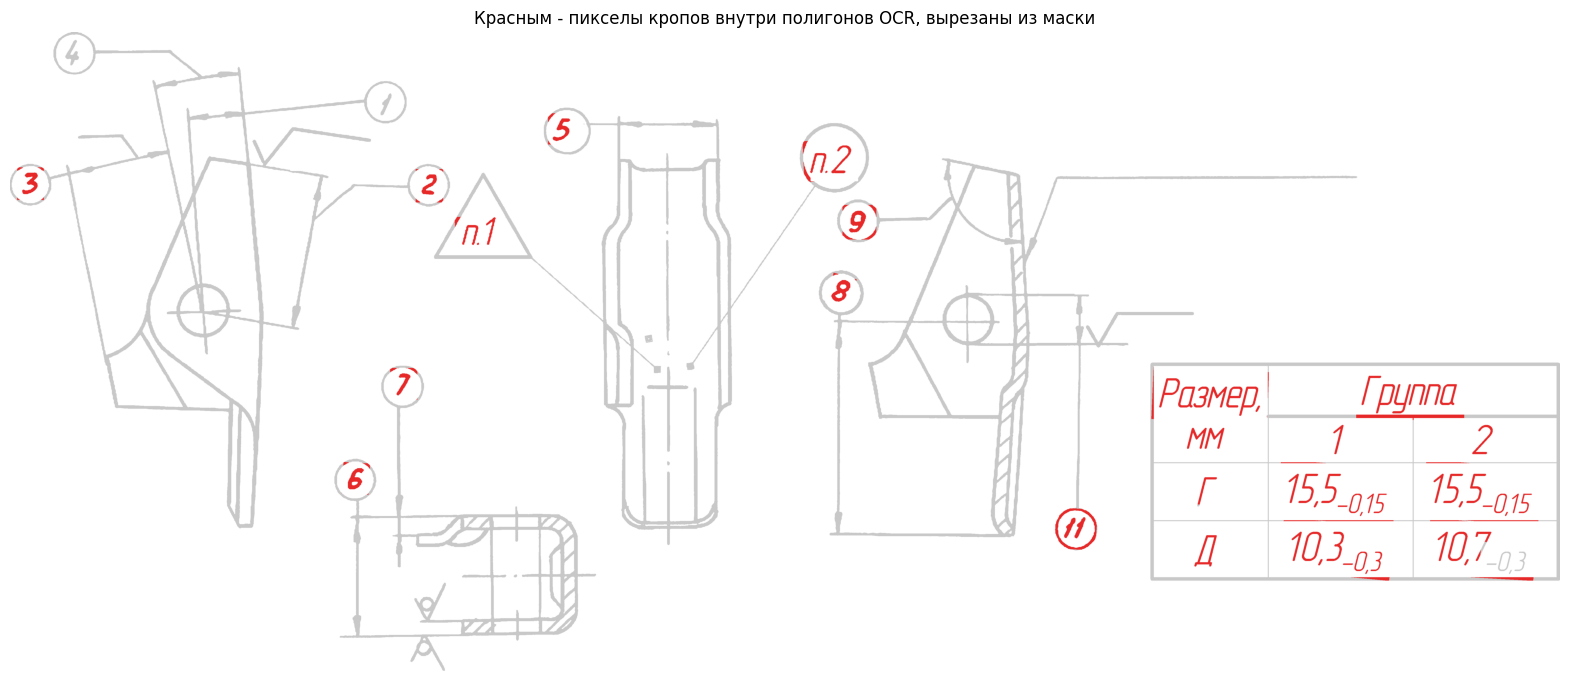

In [992]:
# Текст внутри кропа: OCR по очищенному кропу, полигоны надписей (в координатах кропа)
# вырезаются из маски. Маска в кропе заменяется - скелет ниже строится уже без текста.
canvas = np.full_like(img, 255)
cleaned = []
for c in crops:
    ocr = run_ocr(c.img, ocr_engine)
    text = np.zeros(c.mask.shape, np.uint8)
    if ocr:
        cv2.fillPoly(text, [r.poly.astype(np.int32) for r in ocr], 1)
    text = text.astype(bool)

    box = canvas[c.y : c.y + c.h, c.x : c.x + c.w]
    box[c.mask] = (200, 200, 200)
    box[c.mask & text] = (230, 40, 40)
    print(f"кроп {c.label}: надписей {len(ocr)}, убрано {(c.mask & text).sum()} пикселов: {[r.text for r in ocr]}")
    cleaned.append(replace(c, mask=c.mask & ~text))
crops = cleaned

y0, y1 = min(c.y for c in crops), max(c.y + c.h for c in crops)
x0, x1 = min(c.x for c in crops), max(c.x + c.w for c in crops)
plt.figure(figsize=(20, 20))
plt.imshow(canvas[y0:y1, x0:x1])
plt.axis("off")
plt.title("Красным - пикселы кропов внутри полигонов OCR, вырезаны из маски")
plt.show()

In [993]:
def resize_to_long_side(image, long_side: int):
    current_side = max(image.shape[:2])
    if current_side == long_side:
        return image

    factor = long_side / float(current_side)
    interpolation = cv2.INTER_AREA if factor < 1 else cv2.INTER_CUBIC
    width = round(image.shape[1] * factor)
    height = round(image.shape[0] * factor)
    return cv2.resize(image, (width, height), interpolation=interpolation)

In [ ]:
from types import SimpleNamespace

from draftslice.core.utils.image_utils import binarize_image, rgb_to_grayscale

# Апскейл один для всех кропов: ширина штриха как 2 * расстояние до фона округляется вверх до
# чётного числа рабочих пикселов, шаг измерения - 2 / SCALE px листа. При разном апскейле у кропов
# одного листа (×0.5 / ×1 / ×2 по размеру кропа) шаг был 4 / 2 / 1 px, ширины кропов несравнимы и
# статистика листа размывалась. ×2 даёт шаг 1 px - тонкие в 1 px отличимы от толстых в 3 px.
# Самый большой кроп в данных (8813x3273) при ×2 - 7.5 с и 2.5 ГБ на скелет и расстояния.
SCALE = 2.0

# Кроп (после закрытия и без текста) увеличивается кубической интерполяцией и бинаризуется
# заново: у края линии появляются полутона, ширина штриха меряется точнее. Остальное -
# закрытие, OCR, картинки - остаётся в разрешении исходного листа.
# data - по записи на кроп: ячейки ниже дописывают в неё свои результаты, а не заводят
# параллельные списки, поэтому по кропам везде идёт zip(crops, data).
data = []
for c in crops:
    up = cv2.resize(c.img, (0, 0), fx=SCALE, fy=SCALE, interpolation=cv2.INTER_CUBIC)
    data.append(SimpleNamespace(up_mask=binarize_image(rgb_to_grayscale(up)) > 0, SCALE=SCALE))
    print(f"кроп {c.label}: {c.w}x{c.h} -> {up.shape[1]}x{up.shape[0]}")

In [995]:
from skimage.morphology import skeletonize

# Ширина штриха определена только на средней линии: у края любой линии расстояние до фона мало.
# Берём её на скелете (2 * расстояние до фона) и раздаём пикселам линии от ближайшей точки скелета:
# DIST_LABEL_PIXEL даёт каждой точке скелета свою метку, а каждому пикселу - метку ближайшей точки.
# Всё считается на апскейле, ширины - в пикселах апскейла; попиксельная ширина возвращается к
# размеру кропа. Порог - средняя ширина по скелету своего кропа.
# Ближайшая точка скелета считается здесь один раз: near - плоский индекс ближайшей точки скелета
# для каждого пиксела апскейла, любая карта на скелете раздаётся пикселам через X.ravel()[near].
# int32 хватает и на целый лист после апскейла (~1e8 пикселов), int64 удвоил бы память.
# Одиночные точки скелета выкидываются: skan не кладёт их ни в одну ветку, и номер ветки через
# near у пикселов вокруг них был бы не определён.
for c, d in zip(crops, data, strict=False):
    dist = cv2.distanceTransform(d.up_mask.astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    skel = skeletonize(d.up_mask)
    skel &= cv2.filter2D(skel.astype(np.uint8), -1, np.ones((3, 3))) > 1
    _, lbl = cv2.distanceTransformWithLabels((~skel).astype(np.uint8), cv2.DIST_L2, 5, labelType=cv2.DIST_LABEL_PIXEL)
    lut = np.zeros(lbl.max() + 1, np.int32)
    lut[lbl[skel]] = np.flatnonzero(skel)
    d.near = lut[lbl]

    d.skel_map = np.where(skel, 2 * dist, 0)  # скелет со значением ширины - вход для skan
    d.skel_stroke = 2 * dist[skel]
    d.thresh = np.mean(d.skel_stroke)
    px_up = cv2.resize(d.skel_map.ravel()[d.near], (c.w, c.h), interpolation=cv2.INTER_NEAREST)
    d.px_stroke = np.where(c.mask, px_up, 0)
    print(f"кроп {c.label}: точек скелета {skel.sum()}, порог ширины {d.thresh:.2f} px апскейла")

кроп 1: точек скелета 15423, порог ширины 12.61 px апскейла
кроп 2: точек скелета 27405, порог ширины 22.96 px апскейла
кроп 3: точек скелета 15399, порог ширины 12.35 px апскейла
кроп 4: точек скелета 19704, порог ширины 19.46 px апскейла
кроп 5: точек скелета 19602, порог ширины 22.74 px апскейла


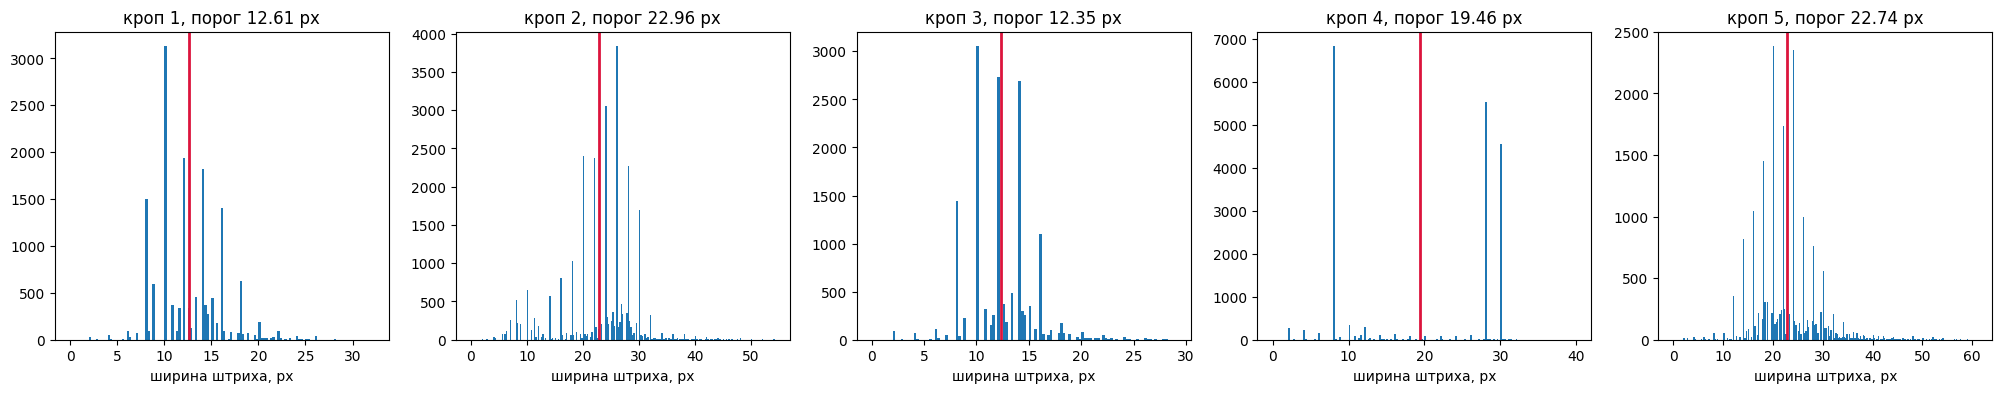

In [996]:
# Гистограмма ширины штриха по скелету каждого кропа: два горба - классы разделимы без апскейла.
fig, axes = plt.subplots(1, len(crops), figsize=(5 * len(crops), 4), squeeze=False)
for ax, c, d in zip(axes[0], crops, data, strict=False):
    ax.hist(d.skel_stroke, bins=np.arange(0, d.skel_stroke.max() + 0.5, 0.25))
    ax.axvline(d.thresh, color="crimson", lw=2)
    ax.set_title(f"кроп {c.label}, порог {d.thresh:.2f} px")
    ax.set_xlabel("ширина штриха, px")
plt.show()

кроп 1: толстых 56% пикселов
кроп 2: толстых 68% пикселов
кроп 3: толстых 53% пикселов
кроп 4: толстых 79% пикселов
кроп 5: толстых 49% пикселов


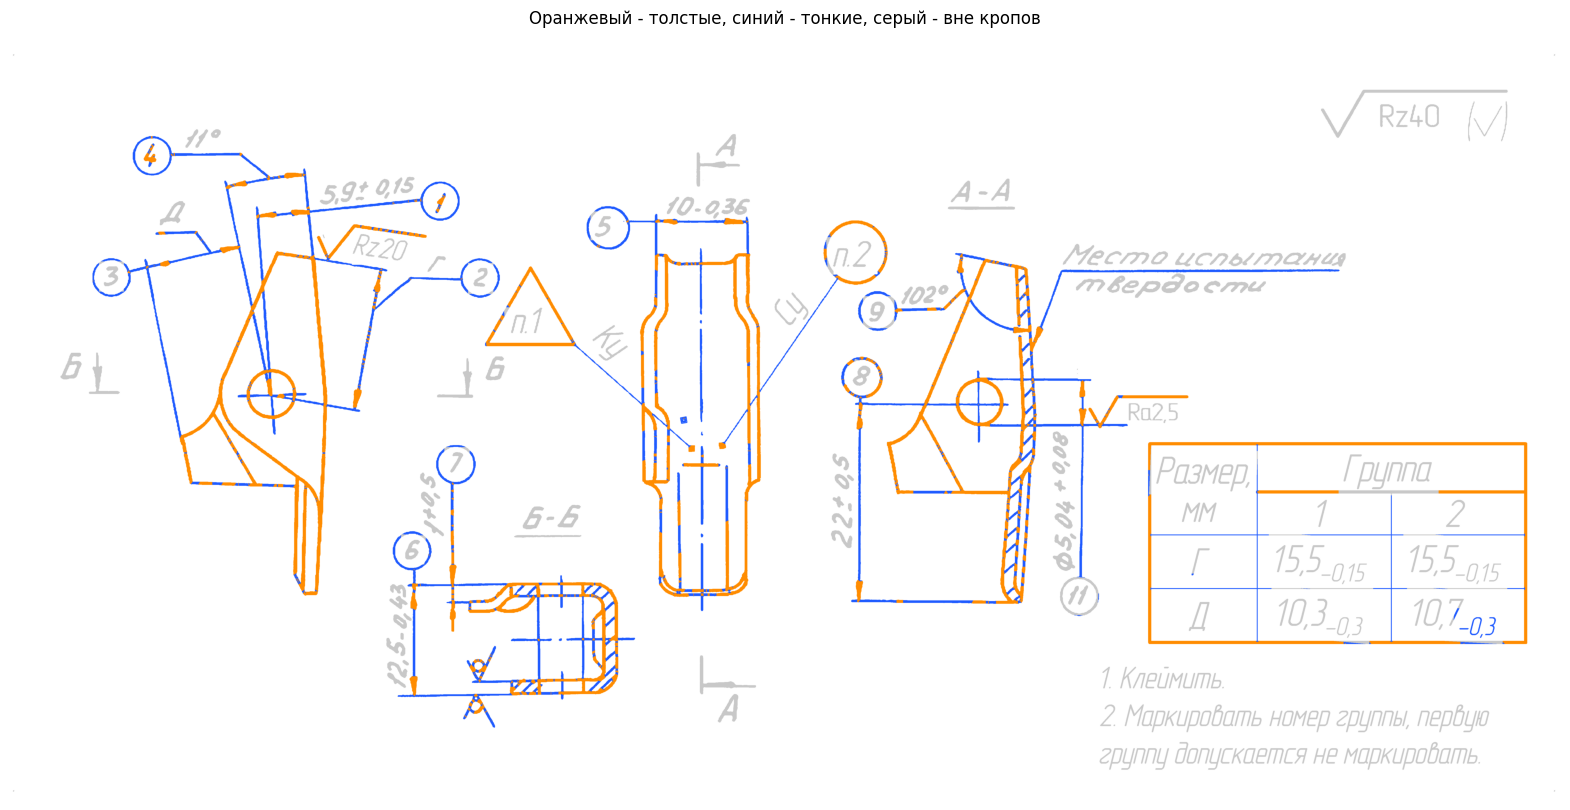

In [997]:
ORANGE = (255, 140, 0)  # толстые
BLUE = (30, 90, 255)  # тонкие

# Все кропы на исходном листе: краска вне кропов - серым.
canvas = np.full_like(img, 255)
canvas[binarize_image(rgb_to_grayscale(img)) > 0] = (200, 200, 200)
for c, d in zip(crops, data, strict=False):
    box = canvas[c.y : c.y + c.h, c.x : c.x + c.w]
    thick = d.px_stroke > d.thresh
    box[thick] = ORANGE
    box[c.mask & ~thick] = BLUE
    print(f"кроп {c.label}: толстых {100 * thick.sum() / c.mask.sum():.0f}% пикселов")

plt.figure(figsize=(20, 20))
plt.imshow(canvas)
plt.axis("off")
plt.title("Оранжевый - толстые, синий - тонкие, серый - вне кропов")
plt.show()

In [998]:
import pandas as pd
from scipy.ndimage import median_filter
from skan import Skeleton, summarize

# Разрез веток по смене толщины. Ширины - в px апскейла, пути - в точках скелета (шаг 1-1.4 px).
MIN_RUN = 15  # ширин штриха (безразмерно): участок другой толщины короче MIN_RUN × ширина ветки - выброс
SPLIT_RATIO = 1.5  # раз (безразмерно): разрез остаётся, если медианы ширины по обе стороны различаются больше


def split_branches(skel_map, thresh):
    """Ветки skan, разрезанные по смене толщины: таблица участков, их пути и точки разреза."""
    sk = Skeleton(skel_map)
    df = summarize(sk, separator="_")
    # Skan режет скелет только в топологических узлах: тонкая линия, которая дальше по прямой
    # становится толстой (наконечник стрелки), - одна ветка. Режем по профилю ширины вдоль пути:
    # класс каждой точки - выше порога кропа или нет, медианный фильтр в MIN_RUN ширин штриха
    # убирает короткие выбросы (стыки, диагональные ступени). Крайний участок короче MIN_RUN ширин
    # не отрезается - это сужение на свободном конце линии или горб на стыке, а медианный фильтр
    # у края пути их не убирает. Внутренние концы участков получают новые номера узлов, по одному
    # на конец, - в пары при склейке они не попадут.
    rows, paths, cuts = [], [], []
    new_node = max(df["node_id_src"].max(), df["node_id_dst"].max()) + 1
    for i, b in enumerate(df.itertuples()):
        p = sk.path_coordinates(i).astype(int)
        w = skel_map[p[:, 0], p[:, 1]]
        lim = MIN_RUN * np.median(w)
        thick = median_filter(w, size=max(1, round(lim)) | 1, mode="nearest") > thresh
        cut = list(np.flatnonzero(np.diff(thick)) + 1)
        if cut and cut[0] < lim:
            cut.pop(0)
        if cut and len(p) - cut[-1] < lim:
            cut.pop()
        # Разрез остаётся, только если медианы ширины соседних участков различаются больше чем в
        # SPLIT_RATIO раз: иначе это шум ширины одной линии вокруг порога. Слабейший разрез
        # убирается первым, медианы соседей после этого пересчитываются.
        while cut:
            bounds = [0, *cut, len(w)]
            med = [np.median(w[bounds[k] : bounds[k + 1]]) for k in range(len(bounds) - 1)]
            ratio = [max(med[k], med[k + 1]) / min(med[k], med[k + 1]) for k in range(len(cut))]
            k = int(np.argmin(ratio))
            if ratio[k] > SPLIT_RATIO:
                break
            cut.pop(k)
        segs = np.split(p, cut)
        for k, s in enumerate(segs):
            src, dst = b.node_id_src, b.node_id_dst
            if k > 0:
                src, new_node = new_node, new_node + 1
            if k < len(segs) - 1:
                dst, new_node = new_node, new_node + 1
                cuts.append(s[-1])
            rows.append(
                {
                    "node_id_src": src,
                    "node_id_dst": dst,
                    "branch_type": b.branch_type if len(segs) == 1 else 1,
                    "branch_distance": np.hypot(*np.diff(s, axis=0).T).sum(),
                    "stroke": np.median(skel_map[s[:, 0], s[:, 1]]),
                    "image_coord_src_0": s[0, 0],
                    "image_coord_src_1": s[0, 1],
                    "image_coord_dst_0": s[-1, 0],
                    "image_coord_dst_1": s[-1, 1],
                }
            )
            paths.append(s)
    return pd.DataFrame(rows), paths, np.array(cuts).reshape(-1, 2)


# blab - номер участка на точках скелета (0 - не скелет).
for c, d in zip(crops, data, strict=False):
    d.df, d.paths, d.cuts = split_branches(d.skel_map, d.thresh)
    d.blab = np.zeros(d.skel_map.shape, np.int32)
    for i, p in enumerate(d.paths):
        d.blab[p[:, 0], p[:, 1]] = i + 1
    print(
        f"кроп {c.label}: участков {len(d.df)}, разрезов по толщине {len(d.cuts)}, "
        f"точек скелета без участка {((d.skel_map > 0) & (d.blab == 0)).sum()}"
    )

кроп 1: участков 110, разрезов по толщине 0, точек скелета без участка 0
кроп 2: участков 124, разрезов по толщине 0, точек скелета без участка 0
кроп 3: участков 145, разрезов по толщине 0, точек скелета без участка 0
кроп 4: участков 47, разрезов по толщине 0, точек скелета без участка 0
кроп 5: участков 159, разрезов по толщине 0, точек скелета без участка 0


In [1011]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# Склейка участков в цепочки по соосности в узлах.
MAX_ANGLE = 25  # градусы: концы продолжают друг друга, если отклонение от прямой не больше
MERGE_RATIO = 1.2  # раз (безразмерно): и медианы ширины двух участков различаются не больше
LOOK = 2  # ширин штриха (безразмерно): направление конца - на точку в LOOK × ширина участка от узла


def end_dir(path, stroke, at_src):
    """Единичный вектор от узла внутрь участка на LOOK ширин штриха."""
    k = min(len(path) - 1, max(1, round(LOOK * stroke)))
    p0, p1 = (path[0], path[k]) if at_src else (path[-1], path[-1 - k])
    v = (p1 - p0).astype(float)
    return v / (np.linalg.norm(v) or 1)


def chain_branches(df, paths):
    """Номер цепочки каждого участка - колонка chain в таблице участков."""
    stroke = df["stroke"].to_numpy()

    # Узлы, соединённые короткой веткой (узел-узел, короче своей ширины штриха), - один узел:
    # на пересечении линий с шириной skeletonize ставит два соседних узла вместо одного, и половины
    # линии, заканчиваясь в разных узлах, иначе не встретились бы при поиске пар.
    src_node, dst_node = df["node_id_src"].to_numpy(), df["node_id_dst"].to_numpy()
    short = (df["branch_type"] == 2).to_numpy() & (df["branch_distance"].to_numpy() <= stroke)
    n_nodes = max(src_node.max(), dst_node.max()) + 1
    _, node = connected_components(
        coo_matrix((np.ones(short.sum()), (src_node[short], dst_node[short])), shape=(n_nodes, n_nodes)),
        directed=False,
    )

    # Концы участков по узлам: путь идёт от node_id_src к node_id_dst. Короткие ветки внутри
    # объединённого узла в пары не идут - направление у них не определено.
    ends, inner = {}, {}
    for i, (src, dst) in enumerate(zip(src_node, dst_node, strict=False)):
        if short[i]:
            inner.setdefault(node[src], []).append(i)
            continue
        ends.setdefault(node[src], []).append((i, end_dir(paths[i], stroke[i], True)))
        ends.setdefault(node[dst], []).append((i, end_dir(paths[i], stroke[i], False)))

    # В узле два конца продолжают друг друга, если направления внутрь участков почти противоположны
    # и ширины близки. Каждый конец берёт одного партнёра - самого соосного, иначе через общий
    # узел склеились бы три линии. Короткие ветки внутри узла уходят в самую соосную пару без
    # проверки ширины: их ширина - ширина стыка, а не линии. На класс цепочки они не влияют -
    # её ширина считается по всем точкам, а у такой ветки их единицы.
    max_cos = np.cos(np.radians(180 - MAX_ANGLE))
    edges = []
    for n, node_ends in ends.items():
        pairs = []
        for a in range(len(node_ends)):
            for b in range(a + 1, len(node_ends)):
                (i, vi), (j, vj) = node_ends[a], node_ends[b]
                ratio = max(stroke[i], stroke[j]) / min(stroke[i], stroke[j])
                if i != j and vi @ vj <= max_cos and ratio <= MERGE_RATIO:
                    pairs.append((vi @ vj, a, b))
        used = set()
        for _, a, b in sorted(pairs):
            if a not in used and b not in used:
                if not used:
                    edges += [(k, node_ends[a][0]) for k in inner.get(n, [])]
                used |= {a, b}
                edges.append((node_ends[a][0], node_ends[b][0]))

    graph = coo_matrix((np.ones(len(edges)), ([i for i, _ in edges], [j for _, j in edges])), shape=(len(df), len(df)))
    _, df["chain"] = connected_components(graph, directed=False)
    return df


for c, d in zip(crops, data, strict=False):
    d.df = chain_branches(d.df, d.paths)
    print(f"кроп {c.label}: участков {len(d.df)} -> цепочек {d.df['chain'].max() + 1}")

кроп 1: участков 110 -> цепочек 62
кроп 2: участков 124 -> цепочек 67
кроп 3: участков 145 -> цепочек 71
кроп 4: участков 47 -> цепочек 31
кроп 5: участков 159 -> цепочек 85


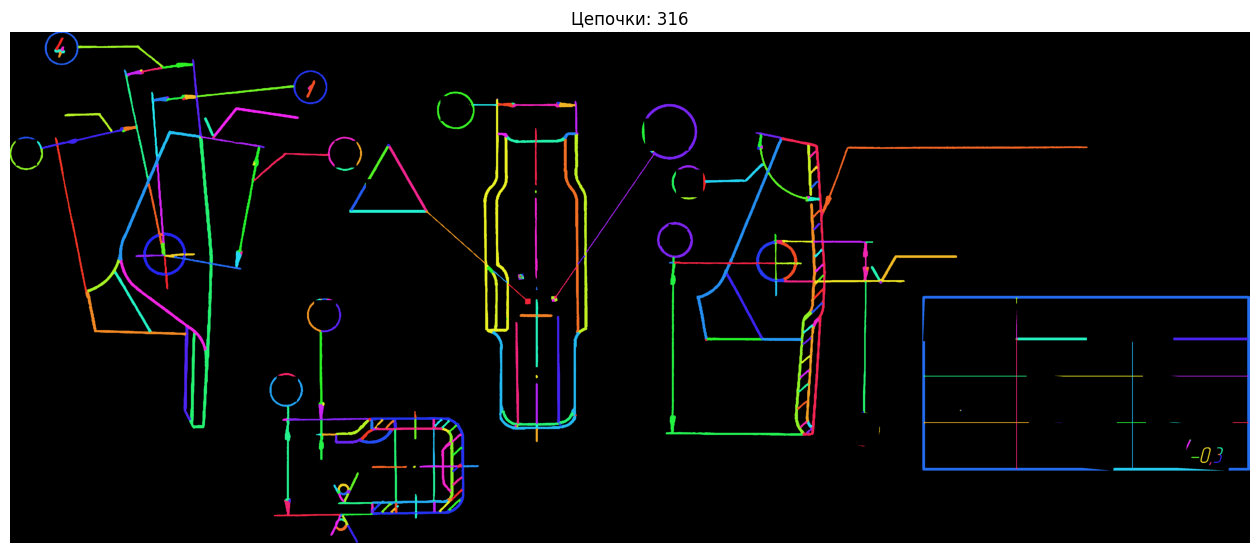

In [1012]:
from draw import colorize

# Ветки и цепочки на листе: каждому пикселу линии - номер ветки ближайшей точки скелета (near из
# ячейки ширины). Скелет на апскейле, карта веток возвращается к размеру кропа ближайшим соседом.
# Номера сдвигаются от кропа к кропу, чтобы не совпадали цвета разных кропов.
branch_img = np.zeros(img.shape[:2], np.int32)
chain_img = np.zeros(img.shape[:2], np.int32)
b_off = ch_off = 0
for c, d in zip(crops, data, strict=False):
    d.branch_up = d.blab.ravel()[d.near] - 1
    d.branch = cv2.resize(d.branch_up, (c.w, c.h), interpolation=cv2.INTER_NEAREST)
    chain = d.df["chain"].to_numpy()
    box = (slice(c.y, c.y + c.h), slice(c.x, c.x + c.w))
    branch_img[box][c.mask] = d.branch[c.mask] + 1 + b_off
    chain_img[box][c.mask] = chain[d.branch[c.mask]] + 1 + ch_off
    b_off += len(d.df)
    ch_off += chain.max() + 1

# Показываем только область кропов - остальной лист пустой.
y0, y1 = min(c.y for c in crops), max(c.y + c.h for c in crops)
x0, x1 = min(c.x for c in crops), max(c.x + c.w for c in crops)
plt.figure(figsize=(16, 8))
plt.imshow(colorize(chain_img[y0:y1, x0:x1]))
plt.title(f"Цепочки: {ch_off}")
plt.axis("off")
plt.show()

кроп 1: узлов 59, склеено 40, не склеено 19, разрезов по толщине 0
кроп 2: узлов 68, склеено 50, не склеено 18, разрезов по толщине 0
кроп 3: узлов 83, склеено 67, не склеено 16, разрезов по толщине 0
кроп 4: узлов 17, склеено 12, не склеено 5, разрезов по толщине 0
кроп 5: узлов 94, склеено 64, не склеено 30, разрезов по толщине 0


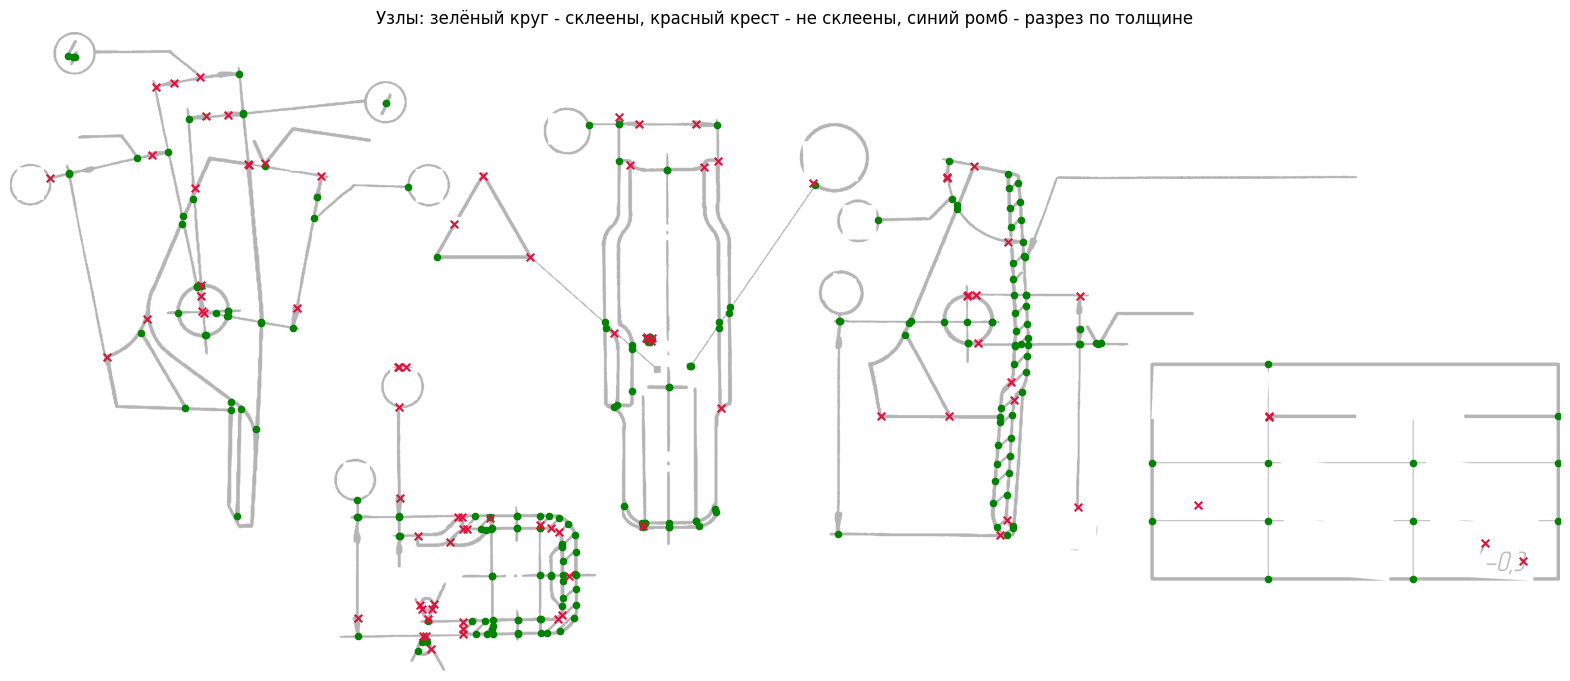

In [1013]:
# Склейка по узлам скелета - прямо, а не по цвету цепочек: у меток с разницей номеров 21, 34, 55...
# оттенок почти совпадает, и две разные цепочки на картинке выше выглядят одной.
# В узле склеено (зелёный круг), если там сходятся концы хотя бы двух веток одной цепочки;
# не склеено (красный крест) - концы сходятся, но ни одна пара не соединилась. Концы линий
# (один конец в узле) не рисуются. Ветка-петля (src == dst) выкидывается: оба её конца в одном
# узле и одной цепочке, узел выглядел бы склеенным. Синий ромб - разрез ветки по смене толщины.
canvas = np.full_like(img, 255)
for c in crops:
    canvas[c.y : c.y + c.h, c.x : c.x + c.w][c.mask] = (180, 180, 180)
plt.figure(figsize=(20, 20))
plt.imshow(canvas[y0:y1, x0:x1])
for c, d in zip(crops, data, strict=False):
    df = d.df[d.df["node_id_src"] != d.df["node_id_dst"]]
    ends = pd.concat(
        [
            df[["node_id_src", "image_coord_src_0", "image_coord_src_1", "chain"]].set_axis(
                ["node", "r", "col", "chain"], axis=1
            ),
            df[["node_id_dst", "image_coord_dst_0", "image_coord_dst_1", "chain"]].set_axis(
                ["node", "r", "col", "chain"], axis=1
            ),
        ]
    )
    nodes = ends.groupby("node").agg(
        r=("r", "first"), col=("col", "first"), n=("chain", "size"), n_chains=("chain", "nunique")
    )
    nodes = nodes[nodes["n"] > 1]
    joined = nodes["n_chains"] < nodes["n"]
    x = c.x + nodes["col"] / d.SCALE - x0
    y = c.y + nodes["r"] / d.SCALE - y0
    plt.scatter(x[joined], y[joined], s=20, c="#008300", marker="o")
    plt.scatter(x[~joined], y[~joined], s=30, c="crimson", marker="x")
    plt.scatter(c.x + d.cuts[:, 1] / d.SCALE - x0, c.y + d.cuts[:, 0] / d.SCALE - y0, s=30, c="#2a78d6", marker="D")
    print(
        f"кроп {c.label}: узлов {len(nodes)}, склеено {joined.sum()}, не склеено {(~joined).sum()}, "
        f"разрезов по толщине {len(d.cuts)}"
    )
plt.axis("off")
plt.title("Узлы: зелёный круг - склеены, красный крест - не склеены, синий ромб - разрез по толщине")
plt.show()

порог листа 11.54 px исходного листа
кроп 1: свой порог был бы 12.45, толстых цепочек 39 из 62
кроп 2: свой порог был бы 11.36, толстых цепочек 26 из 67
кроп 3: свой порог был бы 11.96, толстых цепочек 32 из 71
кроп 4: свой порог был бы 10.31, толстых цепочек 5 из 31
кроп 5: свой порог был бы 10.93, толстых цепочек 31 из 85


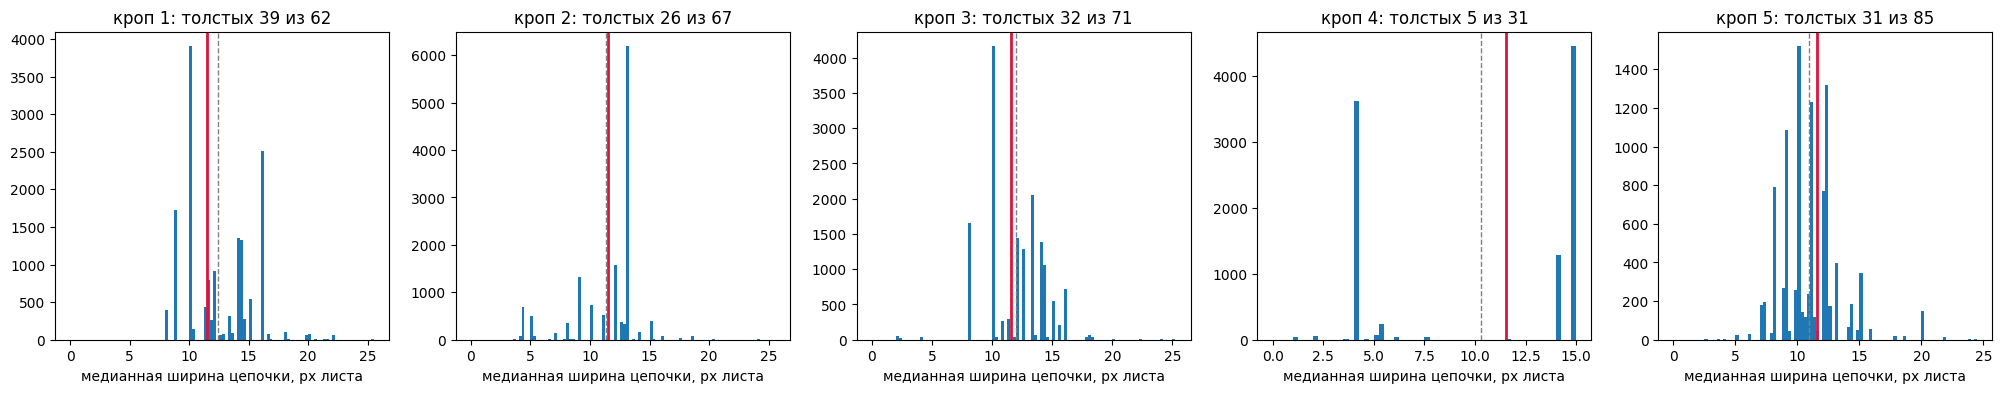

In [1014]:
# Ширина цепочки - медиана по всем её точкам скелета, как и ширина участка: каждая точка линии -
# свой замер ширины. Медиана по участкам давала каждому участку один голос, и кусочки стыка в 1-3
# точки с шириной толстой линии перевешивали тонкую линию в сотни точек.
# Граница тонких и толстых - одна на лист, по готовым линиям всех кропов: среднее ширин цепочек с
# весом их длины. Порог по кропу в кропе без тонких линий всё равно делил линии на две группы.
# Апскейл у каждого кропа свой (adaptive_scale), поэтому ширина и длина переводятся в px исходного
# листа (/ d.SCALE) - иначе ширины разных кропов несравнимы. Класс цепочки - колонка thick в таблице
# участков.
for d in data:
    pts = pd.DataFrame(
        {
            "chain": np.repeat(d.df["chain"].to_numpy(), [len(p) for p in d.paths]),
            "w": np.concatenate([d.skel_map[p[:, 0], p[:, 1]] for p in d.paths]),
        }
    )
    d.chains = pts.groupby("chain").agg(stroke=("w", "median"), length=("w", "size")) / d.SCALE
chains_all = pd.concat([d.chains for d in data])
sheet_thresh = np.average(chains_all["stroke"], weights=chains_all["length"])
print(f"порог листа {sheet_thresh:.2f} px исходного листа")

fig, axes = plt.subplots(1, len(crops), figsize=(5 * len(crops), 4), squeeze=False)
for ax, c, d in zip(axes[0], crops, data, strict=False):
    d.chains["thick"] = d.chains["stroke"] > sheet_thresh
    d.df["thick"] = d.df["chain"].map(d.chains["thick"])
    own = np.average(d.chains["stroke"], weights=d.chains["length"])  # порог только по этому кропу - для сравнения
    print(f"кроп {c.label}: свой порог был бы {own:.2f}, толстых цепочек {d.chains['thick'].sum()} из {len(d.chains)}")

    # По оси Y - суммарная длина цепочек в px листа, а не их число: видно, сколько линии в классе.
    ax.hist(d.chains["stroke"], bins=np.arange(0, d.chains["stroke"].max() + 0.25, 0.25), weights=d.chains["length"])
    ax.axvline(sheet_thresh, color="crimson", lw=2)
    ax.axvline(own, color="gray", ls="--", lw=1)
    ax.set_title(f"кроп {c.label}: толстых {d.chains['thick'].sum()} из {len(d.chains)}")
    ax.set_xlabel("медианная ширина цепочки, px листа")
plt.show()

кроп 1: толстых 67% пикселов
кроп 2: толстых 76% пикселов
кроп 3: толстых 65% пикселов
кроп 4: толстых 82% пикселов
кроп 5: толстых 42% пикселов


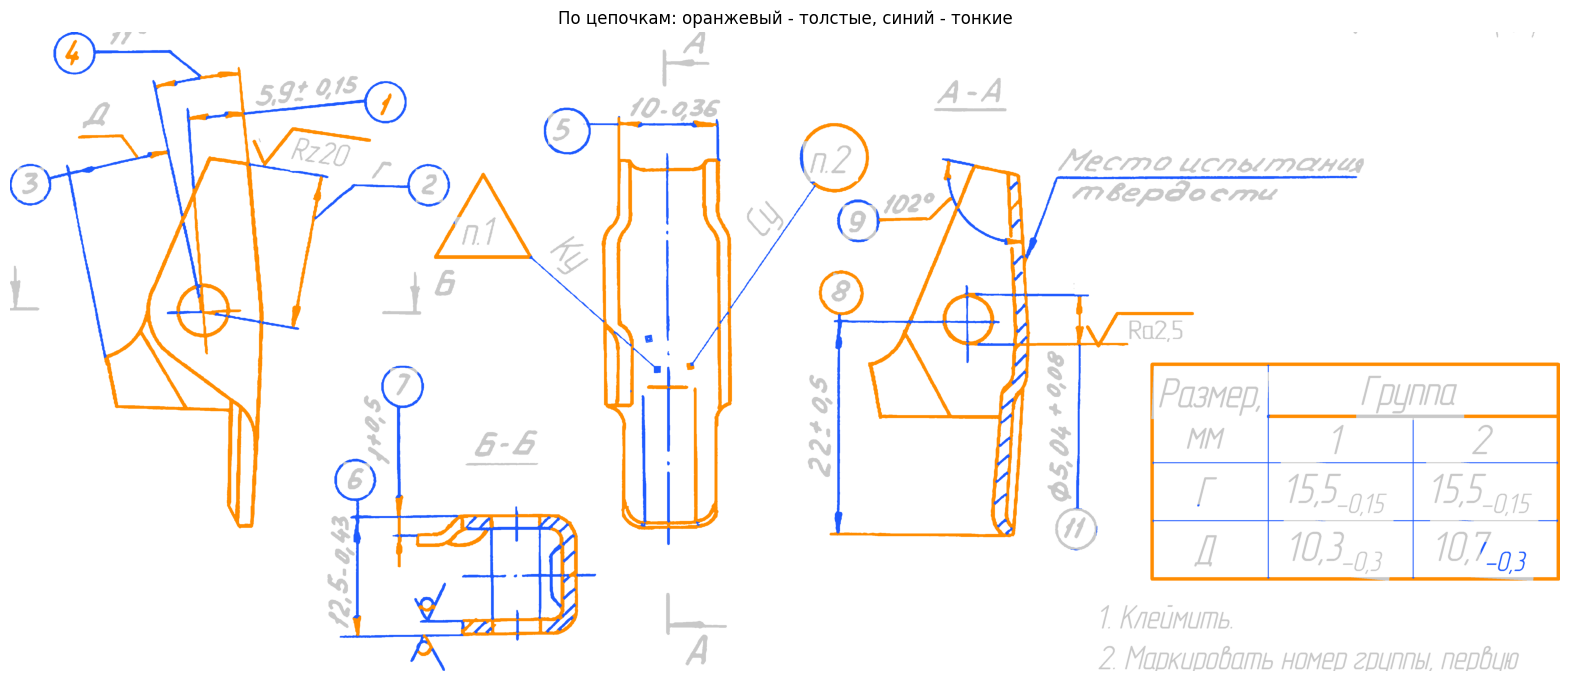

In [1015]:
# Класс цепочки - на все её пикселы: линия целиком либо толстая, либо тонкая.
canvas = np.full_like(img, 255)
canvas[binarize_image(rgb_to_grayscale(img)) > 0] = (200, 200, 200)
for c, d in zip(crops, data, strict=False):
    box = canvas[c.y : c.y + c.h, c.x : c.x + c.w]
    thick = c.mask & d.df["thick"].to_numpy()[d.branch]
    box[c.mask & ~thick] = BLUE
    box[thick] = ORANGE
    print(f"кроп {c.label}: толстых {100 * thick.sum() / c.mask.sum():.0f}% пикселов")

plt.figure(figsize=(20, 20))
plt.imshow(canvas[y0:y1, x0:x1])
plt.axis("off")
plt.title("По цепочкам: оранжевый - толстые, синий - тонкие")
plt.show()

кроп 1: остаётся 68% пикселов
кроп 2: остаётся 77% пикселов
кроп 3: остаётся 68% пикселов
кроп 4: остаётся 82% пикселов
кроп 5: остаётся 47% пикселов


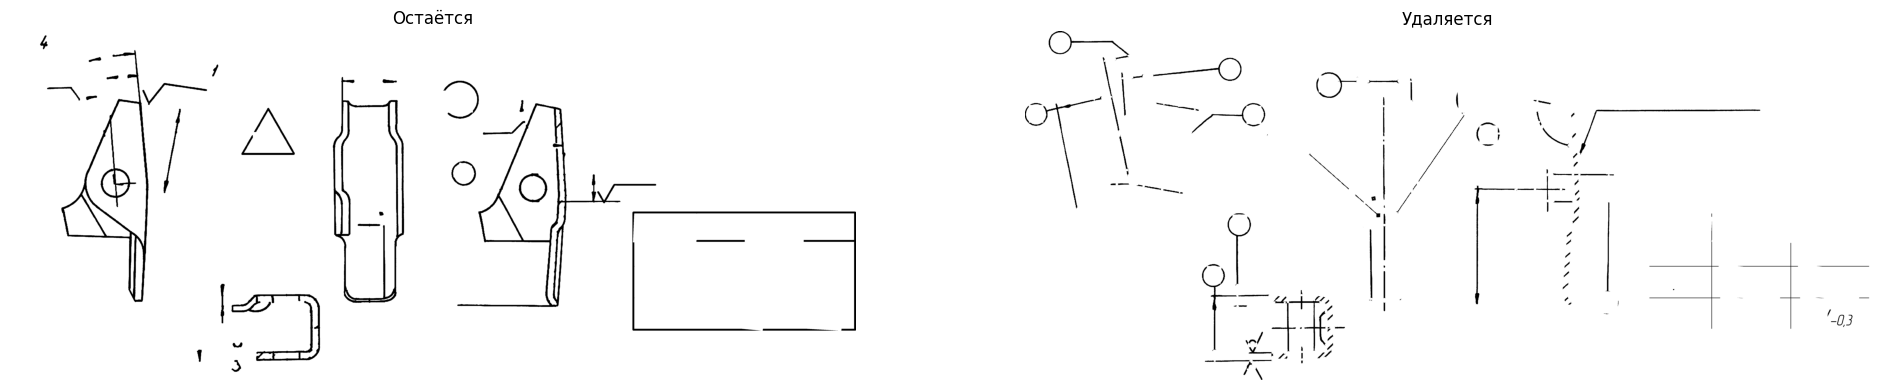

In [1016]:
# Толстые линии восстанавливаем двумя способами и берём объединение:
# 1) максимальные диски точек скелета толстых цепочек - штрих равен объединению своих дисков,
#    это закрывает клин внутри контура на стыке с тонкой линией, где была выемка;
# 2) принадлежность пиксела ближайшей ветке (branch_up из ячейки веток) - это закрывает кромку
#    штриха, которую диски недобирают: skeletonize даёт утончённый скелет, а не полную срединную ось.
# Для дисков расстояние считается до ближайшей точки только толстого скелета: у клина на стыке
# ближайшей может оказаться точка тонкой линии, и по общему near диск толстой его бы не взял.
# Карта классов плотная - по ней обрезать нельзя: маска апскейла бинаризована заново, её край
# не совпадает с краем c.mask, и пересечение с ней съедало кромку линии. Уменьшаем плотную карту
# и пересекаем только с c.mask - за пределы кропа линия всё равно не выйдет.
keep_img = np.full_like(img, 255)
drop_img = np.full_like(img, 255)
for c, d in zip(crops, data, strict=False):
    thick_branch = d.df["thick"].to_numpy()
    thick_skel = np.r_[False, thick_branch][d.blab]  # blab 0 - не скелет

    dist, lbl = cv2.distanceTransformWithLabels(
        (~thick_skel).astype(np.uint8), cv2.DIST_L2, 5, labelType=cv2.DIST_LABEL_PIXEL
    )
    r = np.zeros(lbl.max() + 1)
    r[lbl[thick_skel]] = d.skel_map[thick_skel] / 2  # радиус максимального диска = половина ширины штриха
    disks = dist <= r[lbl]
    own = thick_branch[d.branch_up]

    thick_up = (disks | own).astype(np.uint8)
    d.clean_mask = cv2.resize(thick_up, (c.w, c.h), interpolation=cv2.INTER_NEAREST).astype(bool) & c.mask

    box = (slice(c.y, c.y + c.h), slice(c.x, c.x + c.w))
    keep_img[box][d.clean_mask] = (0, 0, 0)
    drop_img[box][c.mask & ~d.clean_mask] = (0, 0, 0)
    print(f"кроп {c.label}: остаётся {100 * d.clean_mask.sum() / c.mask.sum():.0f}% пикселов")

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].imshow(keep_img[y0:y1, x0:x1])
axes[0].set_title("Остаётся")
axes[1].imshow(drop_img[y0:y1, x0:x1])
axes[1].set_title("Удаляется")
for ax in axes:
    ax.axis("off")
plt.show()